In [1]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import os
import pandas as pd
from torchvision.io import decode_image
import glob
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


In [2]:
%load_ext autoreload
%autoreload 2


Failed to read module file 'C:\Users\jsonp\AppData\Roaming\uv\python\cpython-3.11.13-windows-x86_64-none\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\jsonp\Documents\MLharvest\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jsonp\Documents\MLharvest\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jsonp\AppData\Roaming\uv\python\cpython-3.11.13-windows-x86_64-none\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", li

## Using someone else's method to return a random datetime string within bounds

In [3]:
# Source - https://stackoverflow.com/a/553320
# Posted by Tom Alsberg, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-11, License - CC BY-SA 4.0

import random
import time


def str_time_prop(start, end, time_format, prop):
    """Get a time at a proportion of a range of two formatted times.

    start and end should be strings specifying times formatted in the
    given format (strftime-style), giving an interval [start, end].
    prop specifies how a proportion of the interval to be taken after
    start.  The returned time will be in the specified format.
    """

    stime = time.mktime(time.strptime(start, time_format))
    etime = time.mktime(time.strptime(end, time_format))

    ptime = stime + prop * (etime - stime)

    return time.strftime(time_format, time.localtime(ptime))


def random_date(start, end, prop):
    # return str_time_prop(start, end, '%m/%d/%Y %I:%M %p', prop)
    return str_time_prop(start, end, "%m-%d-%Y %I:%M %p", prop)


print(random_date("1-1-2016 12:00 PM", "1-1-2025 12:00 PM", random.random()))


10-29-2023 09:01 PM


In [4]:
some_date = random_date("1-1-2016 12:00 PM", "1-1-2025 12:00 PM", random.random())

some_date = some_date.split(" ")[0]

N = 302


In [5]:
def rename_file(old_name, img_dir):
    # old_name = "original_file.txt"
    some_date = random_date("1-1-2016 12:00 PM", "1-1-2025 12:00 PM", random.random())

    some_date = some_date.split(" ")[0]

    new_name = os.path.join(img_dir, some_date)
    new_name += ".png"

    try:
        os.rename(old_name, new_name)
        print(f"File '{old_name}' renamed to '{new_name}' successfully.")
    except FileNotFoundError:
        print(f"Error: The file '{old_name}' was not found.")
    except FileExistsError:
        print(f"Error: The file '{new_name}' already exists.")
    except PermissionError:
        print("Error: Permission denied.")


## TEMPORARY FAKE DATA CREATION

In [6]:
img_dir = os.path.join("..", "data", "timetagged")
img_dir = os.path.abspath(img_dir)

In [7]:
# Uncomment to rename fake data
# print(img_dir)
# for abs_path in glob.glob(os.path.join(img_dir, "*.png")):
#     rename_file(old_name=abs_path, img_dir=img_dir)

In [8]:
data_df = pd.DataFrame(
    {
        "filename": [
            f"{some_date.split('-')[0]}-{some_date.split('-')[1]}-{some_date.split('-')[2]}"
            for some_date in os.listdir(img_dir)
        ],
        "label": [int(x.split("-")[0]) for x in os.listdir(img_dir)],
    }
)
data_df

,filename,label
0,01-01-2019.png,1
1,01-03-2018.png,1
2,01-04-2018.png,1
3,01-07-2024.png,1
4,01-12-2020.png,1
...,...,...
154,12-26-2021.png,12
155,12-28-2020.png,12
156,12-29-2018.png,12
157,12-30-2022.png,12


## Dataset Class

In [9]:
from data import CustomImageDataset
# class CustomImageDataset(Dataset):
#     def __init__(self, img_dir, transform=None, target_transform=None):
#         self.img_labels = None  # start as None, gets filled in by temporary labeling
#         self.img_dir = img_dir
#         self._temporary_labeling()

#     def _temporary_labeling(self):
#         """Gets called in object construction to label images based on filenames."""
#         labels = []
#         for filename in os.listdir(self.img_dir):
#             # Example: Extract month from filename '05-15-2025.png'
#             month = int(filename.split("-")[0])
#             labels.append(month)
#         self.img_labels = pd.DataFrame(
#             {"filename": os.listdir(self.img_dir), "label": labels}
#         )

#     def __len__(self):
#         return len(self.img_labels)

#     def __getitem__(self, idx):
#         img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
#         image = decode_image(img_path)
#         label = self.img_labels.iloc[idx, 1]
#         return image, label

#     def get_dataframe(self, train_test_split=0.2, val_split=0.2):
#         """Get the train, val, test dataframes using sklearn's train_test_split."""
#         # return train_df, val_df, test_df
#         raise NotImplementedError("This method is not implemented yet.")

dataset = CustomImageDataset(img_dir=img_dir)

### Visualizing some random images from the dataset

dataset has  159  images


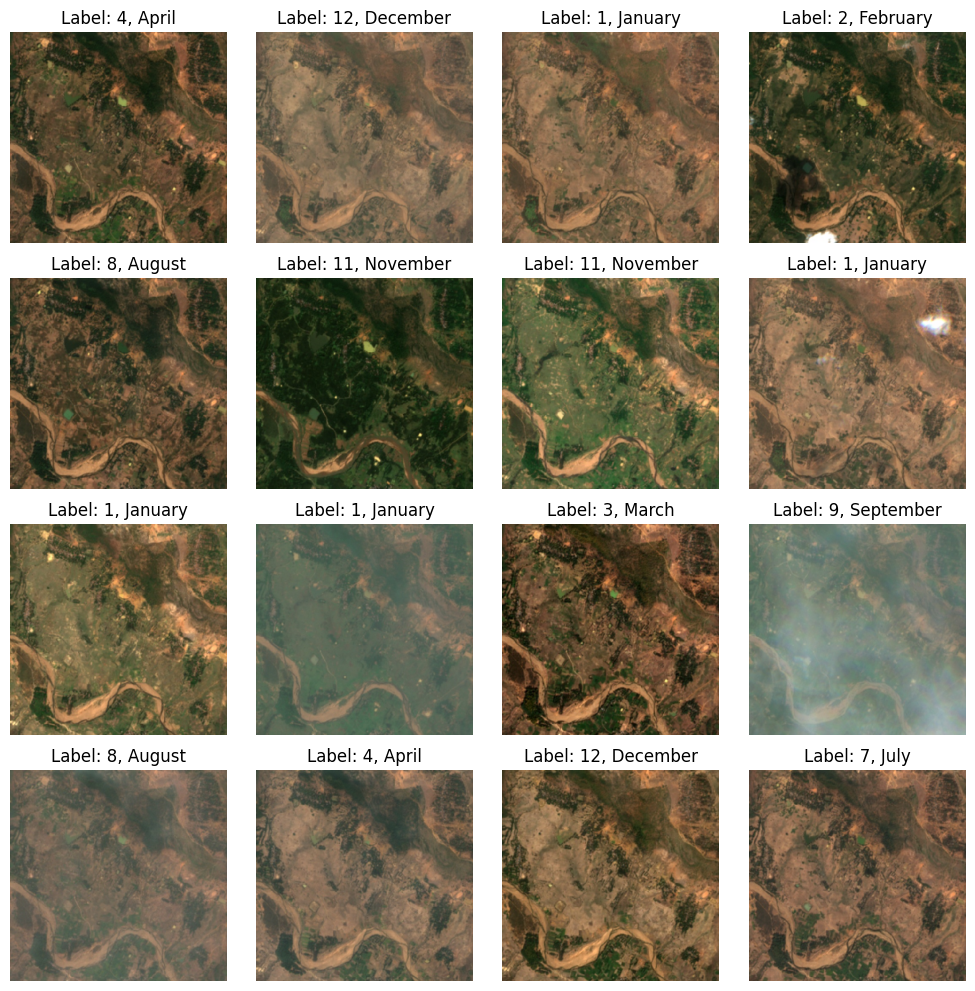

In [10]:
# print(img_dir)

months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}
print("dataset has ", len(dataset), " images")
n = 4
fig, ax = plt.subplots(n, n, figsize=(10, 10))
indices = np.random.choice(len(dataset), n*n, replace=False)
for idx, i in enumerate(indices):
    image, label = dataset[i]
    row, col = idx // n, idx % n
    ax[row, col].imshow(image.permute(1, 2, 0).numpy())
    ax[row, col].set_title(f"Label: {int(label)}, {months[label]}")
    ax[row, col].axis('off')
plt.tight_layout()
plt.show()


In [11]:
import torch
from torch.utils.data import random_split, DataLoader, Dataset
import math

In [12]:
train_percent = 0.8
val_percent = 0.1
test_percent = 0.1

train_size = int(len(dataset) * train_percent)
val_size = int(len(dataset) * val_percent)
test_size = len(dataset) - train_size - val_size # Ensure all data is used

seed = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, 
    [train_size, val_size, test_size], 
    generator=seed
)

print(f"Train size: {len(train_dataset)}, Validation size: {len(val_dataset)}, Test size: {len(test_dataset)}")


Train size: 127, Validation size: 15, Test size: 17


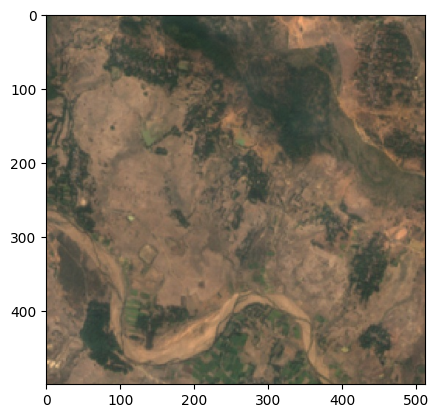

In [13]:
plt.imshow(train_dataset[0][0].permute(1, 2, 0).numpy())

In [14]:
BATCH_SIZE = 32
NUM_WORKERS = 2  # set to 0 if you hit multiprocessing errors on Windows
PIN_MEMORY = torch.cuda.is_available()  # only useful when a GPU is present

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0)


In [15]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 12)  # 12 output classes for months
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print(device)

cuda


In [16]:
import torchvision.transforms.functional as TF

# ImageNet normalization expected by pretrained ResNet weights
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def normalize(imgs):
    """Scale uint8 to [0,1] then apply ImageNet mean/std normalization."""
    imgs = imgs.float() / 255.0
    return (imgs - IMAGENET_MEAN) / IMAGENET_STD


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs   = normalize(imgs.to(device))
        labels = labels.long() - 1           # months 1–12 -> 0-indexed 0–11
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = normalize(imgs.to(device))
            labels = labels.long() - 1       # months 1–12 -> 0-indexed 0–11
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    accuracy = correct / len(loader.dataset)
    return total_loss / len(loader), accuracy


In [17]:

train_losses = []
val_losses = []
val_accs = []
best_val_acc = 0
best_model_path = "best_harvest_model.pt"

for epoch in tqdm(range(3)):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch + 1}: "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"(val_acc: {best_val_acc:.4f})")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")


 33%|███▎      | 1/3 [00:08<00:17,  8.94s/it]

Epoch 1: train_loss=2.6005 | val_loss=2.4044 | val_acc=0.1333
(val_acc: 0.1333)


 67%|██████▋   | 2/3 [00:10<00:04,  4.48s/it]

Epoch 2: train_loss=1.8933 | val_loss=2.4582 | val_acc=0.1333


100%|██████████| 3/3 [00:11<00:00,  3.88s/it]

Epoch 3: train_loss=1.4673 | val_loss=2.5327 | val_acc=0.0667

Best validation accuracy: 0.1333


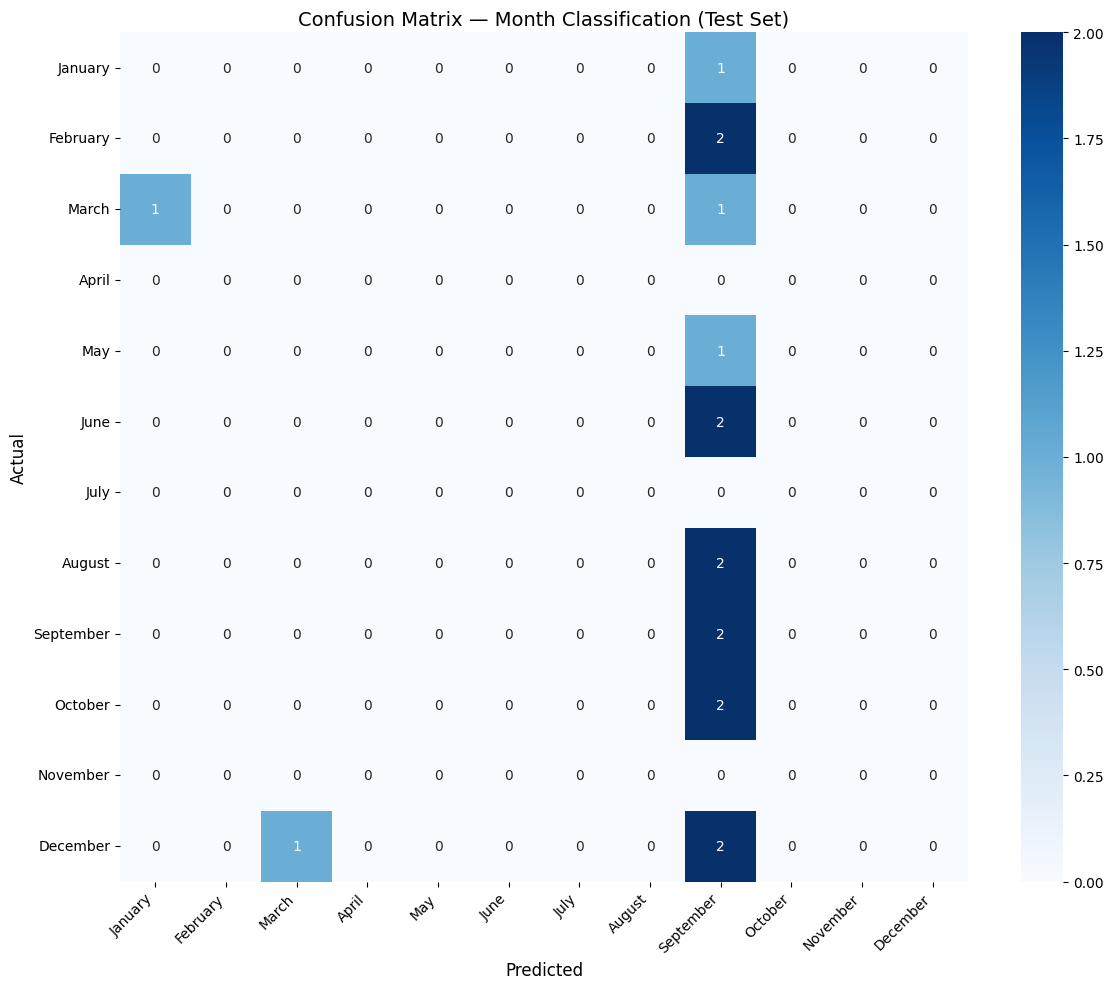

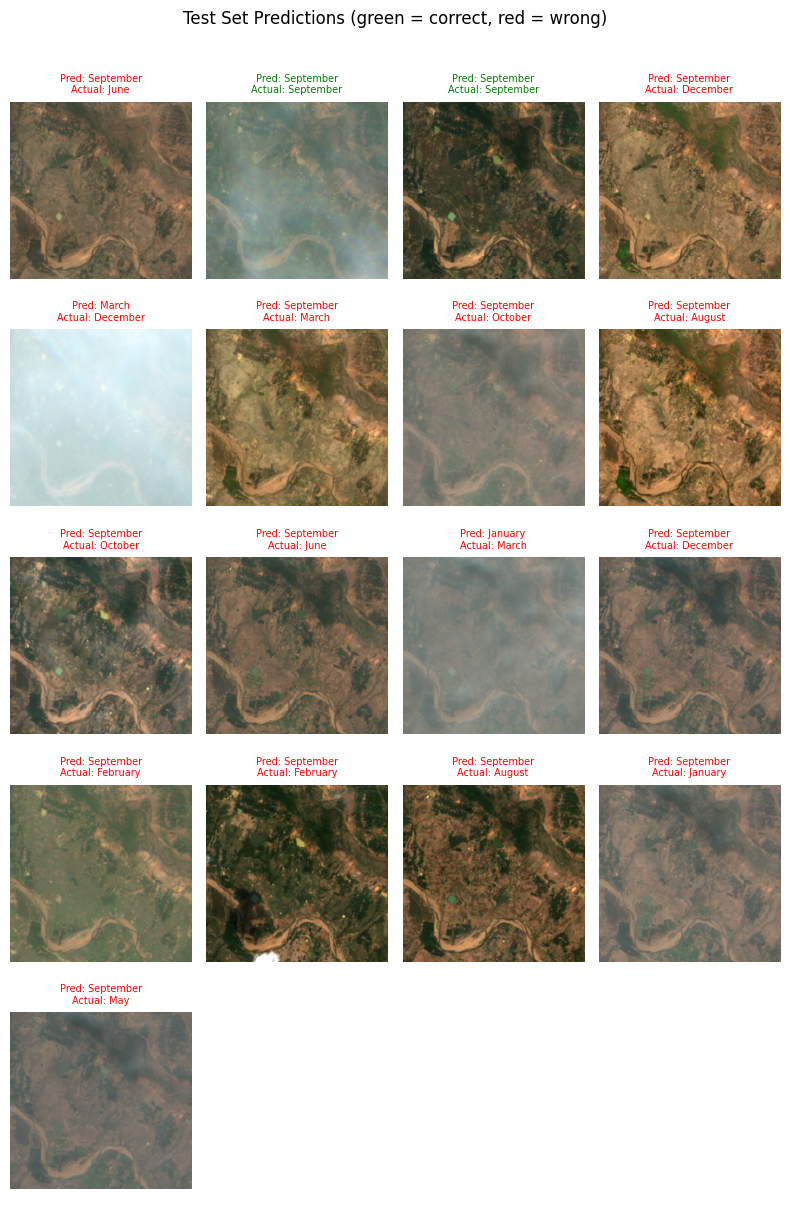

In [19]:
# Collect images + predictions over the test set
model.eval()
all_imgs_cpu = []
all_preds_grid = []
all_labels_grid = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_f = imgs.float() / 255.0
        labels_l = labels.long() - 1        # 1–12 -> 0–11
        outputs = model(imgs_f.to(device))
        preds = outputs.argmax(dim=1).cpu()
        all_imgs_cpu.extend(imgs.cpu())     # keep original uint8 for display
        all_preds_grid.extend(preds.tolist())
        all_labels_grid.extend(labels_l.tolist())

n_imgs = len(all_imgs_cpu)
n_cols = 4
n_rows = math.ceil(n_imgs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.4))
axes = axes.flatten()

for i, (img, pred, actual) in enumerate(zip(all_imgs_cpu, all_preds_grid, all_labels_grid)):
    axes[i].imshow(img.permute(1, 2, 0).numpy())
    pred_name = months[pred + 1]
    actual_name = months[actual + 1]
    correct = pred == actual
    color = "green" if correct else "red"
    axes[i].set_title(f"Pred: {pred_name}\nActual: {actual_name}", fontsize=7, color=color)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Test Set Predictions (green = correct, red = wrong)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("test_set_predictions.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Collect all predictions and ground-truth labels from the test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.float() / 255.0
        labels = labels.long() - 1           # 1–12 → 0–11
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds, labels=list(range(12)))
month_names = [months[m] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=month_names,
    yticklabels=month_names,
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix — Month Classification (Test Set)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
